<a href="https://colab.research.google.com/github/eldhosekroy/churn_prediction/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Candidate Churn Prediction Model
================================
This script builds a machine learning model to predict candidate churn
using candidate profile, call log, and executive profile datasets.
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,
                             roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
#import xgboost

import matplotlib.pyplot as plt
import seaborn as sns
import os
# Remove any duplicate xgboost installation by checking first
import subprocess
import sys

# Step 1: Uninstall the broken version
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "xgboost", "-y"])

# Step 2: Reinstall a stable version
subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])

# Step 3: Import XGBClassifier
from xgboost import XGBClassifier

# Step 4: Restart kernel and test
import xgboost
print(f"XGBoost version: {xgboost.__version__}")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("="*80)
print("CANDIDATE CHURN PREDICTION MODEL")
print("="*80)

XGBoost version: 3.2.0
CANDIDATE CHURN PREDICTION MODEL


In [4]:
# =============================================================================
# 1. DATA LOADING
# =============================================================================
print("\n" + "="*80)
print("STEP 1: DATA LOADING")
print("="*80)

# Load datasets
# In Colab, __file__ is not defined. Use os.getcwd() to reference the current directory.
base_dir = os.getcwd()

candidate_file = os.path.join(base_dir, 'Candidate Profile.csv')
call_log_file = os.path.join(base_dir, 'Call log.csv')
executive_file = os.path.join(base_dir, 'Executive Profile.csv')

try:
    candidate_profile = pd.read_csv(candidate_file)
    call_log = pd.read_csv(call_log_file)
    executive_profile = pd.read_csv(executive_file)

    print(" All datasets loaded successfully!")
    print(f"\n Dataset Shapes:")
    print(f"   - Candidate Profile: {candidate_profile.shape[0]} rows, {candidate_profile.shape[1]} columns")
    print(f"   - Call Log: {call_log.shape[0]} rows, {call_log.shape[1]} columns")
    print(f"   - Executive Profile: {executive_profile.shape[0]} rows, {executive_profile.shape[1]} columns")

except FileNotFoundError as e:
    print(f" Error loading datasets: {e}")
    print("Please ensure all CSV files are in the same directory as model.py.")
    sys.exit(1)

# Display first few rows
print("\n Candidate Profile Sample:")
print(candidate_profile.head(3))
print("\n Call Log Sample:")
print(call_log.head(3))
print("\n Executive Profile Sample:")
print(executive_profile.head(3))


STEP 1: DATA LOADING
 All datasets loaded successfully!

 Dataset Shapes:
   - Candidate Profile: 50 rows, 21 columns
   - Call Log: 123 rows, 6 columns
   - Executive Profile: 10 rows, 11 columns

 Candidate Profile Sample:
  Candidate_ID Candidate_Name            Mail_ID  Mobile_Number    Source  \
0        C0001          Aarav  aarav@example.com     9123456789  LinkedIn   
1        C0002           Diya   diya@example.com     9876543210   College   
2        C0003          Rahul  rahul@example.com     9988776655  Referral   

   Education Background          Role  Experience Current_status  Career_gap  \
0  BTech2019       Tech  Professional           4        Working           0   
1    BSc2021    NonTech       Student           0       Studying           0   
2    MCA2018       Tech  Professional           5        Working           0   

     Stream       Course     Mode Induction_Session  Feedback  \
0   Project    FullStack   Online          Attended  Positive   
1  Training  D

In [5]:
# =============================================================================
# 2. DATA HANDLING & EXPLORATION
# =============================================================================
print("\n" + "="*80)
print("STEP 2: DATA HANDLING & EXPLORATION")
print("="*80)

print("\n Candidate Profile Info:")
print(candidate_profile.info())
print("\n Call Log Info:")
print(call_log.info())
print("\n Executive Profile Info:")
print(executive_profile.info())

# Check for missing values
print("\n Missing Values in Candidate Profile:")
print(candidate_profile.isnull().sum())
print("\n Missing Values in Call Log:")
print(call_log.isnull().sum())
print("\n Missing Values in Executive Profile:")
print(executive_profile.isnull().sum())


STEP 2: DATA HANDLING & EXPLORATION

 Candidate Profile Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Candidate_ID       50 non-null     object
 1   Candidate_Name     50 non-null     object
 2   Mail_ID            50 non-null     object
 3   Mobile_Number      50 non-null     int64 
 4   Source             50 non-null     object
 5   Education          50 non-null     object
 6   Background         50 non-null     object
 7   Role               50 non-null     object
 8   Experience         50 non-null     int64 
 9   Current_status     50 non-null     object
 10  Career_gap         50 non-null     int64 
 11  Stream             50 non-null     object
 12  Course             50 non-null     object
 13  Mode               50 non-null     object
 14  Induction_Session  50 non-null     object
 15  Feedback           50 non-null


STEP 3: DEFINE CHURN TARGET VARIABLE

 Churn Distribution:
Churn
0    39
1    11
Name: count, dtype: int64

Churn Rate: 22.00%


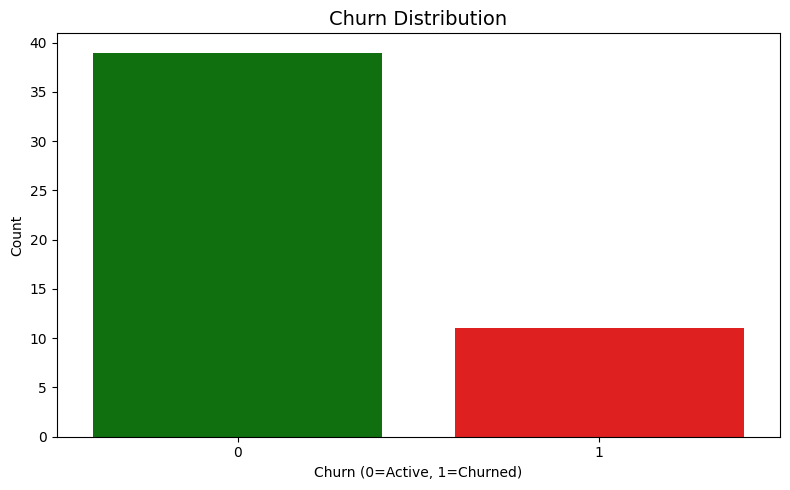

 Saved: churn_distribution.png


In [6]:
# =============================================================================
# 3. DEFINE CHURN TARGET
# =============================================================================
print("\n" + "="*80)
print("STEP 3: DEFINE CHURN TARGET VARIABLE")
print("="*80)

"""
Churn Definition Logic:
- A candidate is considered 'churned' if:
  1. They haven't joined in their training session (Training_Session notjoined)
"""

# Create churn label based on Training_Session
def define_churn(row):
    """
    Define churn based on multiple criteria:
    - Training Session: not completed, pending, notjoined
    """
    training_incomplete = ['not started', 'pending', 'incomplete', 'not completed', 'notjoined']

    if pd.notna(row['Training_Session']):
        if any(status in str(row['Training_Session']).lower() for status in training_incomplete):
            return 1
    return 0

candidate_profile['Churn'] = candidate_profile.apply(define_churn, axis=1)

print("\n Churn Distribution:")
churn_counts = candidate_profile['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {churn_counts[1] / len(candidate_profile) * 100:.2f}%")

# Visualize churn distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=candidate_profile, palette=['green', 'red'])
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn (0=Active, 1=Churned)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=100)
plt.show()
print(" Saved: churn_distribution.png")

In [7]:
# =============================================================================
# 4. DATA PREPROCESSING
# =============================================================================
print("\n" + "="*80)
print("STEP 4: DATA PREPROCESSING")
print("="*80)

# 4.1 Handle Missing Values in Candidate Profile
print("\n Handling Missing Values...")

# Numerical columns - fill with median
numerical_cols = candidate_profile.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['Candidate_ID', 'Churn']]

# Categorical columns - fill with mode
categorical_cols = candidate_profile.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['Candidate_ID', 'Mail_ID', 'Mobile_Number']]

print(f"   Numerical columns: {numerical_cols}")
print(f"   Categorical columns: {categorical_cols}")

# Create copies for processing
df_candidate = candidate_profile.copy()

# Fill numerical missing values
for col in numerical_cols:
    if col in df_candidate.columns:
        df_candidate[col] = df_candidate[col].fillna(df_candidate[col].median())

# Fill categorical missing values
for col in categorical_cols:
    if col in df_candidate.columns:
        df_candidate[col] = df_candidate[col].fillna(df_candidate[col].mode()[0] if len(df_candidate[col].mode()) > 0 else 'Unknown')

# 4.2 Handle Date Columns
print("\n Processing Date Columns...")

# Convert date columns to datetime
date_cols = ['Payment_Date']
for col in date_cols:
    if col in df_candidate.columns:
        df_candidate[col] = pd.to_datetime(df_candidate[col], errors='coerce')

if 'Payment_Date' in df_candidate.columns:
    reference_date = pd.Timestamp.today().normalize()
    df_candidate['Days_Since_Payment'] = (reference_date - df_candidate['Payment_Date']).dt.days
    df_candidate['Days_Since_Payment'] = df_candidate['Days_Since_Payment'].fillna(0)

# 4.3 Calculate Payment Ratio
print("\n Calculating Payment Metrics...")

df_candidate['Payment_Ratio'] = np.where(
    df_candidate['Total_Amount'] > 0,
    df_candidate['Paid_amount'] / df_candidate['Total_Amount'],
    0
)
df_candidate['Payment_Ratio'] = df_candidate['Payment_Ratio'].fillna(0)

# Handle infinite values
df_candidate['Payment_Ratio'] = df_candidate['Payment_Ratio'].replace([np.inf, -np.inf], 0)

print(f"   Payment Ratio Range: {df_candidate['Payment_Ratio'].min():.2f} - {df_candidate['Payment_Ratio'].max():.2f}")


STEP 4: DATA PREPROCESSING

 Handling Missing Values...
   Numerical columns: ['Mobile_Number', 'Experience', 'Career_gap', 'Total_Amount', 'Paid_amount']
   Categorical columns: ['Candidate_Name', 'Source', 'Education', 'Background', 'Role', 'Current_status', 'Stream', 'Course', 'Mode', 'Induction_Session', 'Feedback', 'Training_Session', 'Payment_Method', 'Payment_Date']

 Processing Date Columns...

 Calculating Payment Metrics...
   Payment Ratio Range: 0.00 - 1.00


In [8]:
# =============================================================================
# 5. FEATURE ENGINEERING
# =============================================================================
print("\n" + "="*80)
print("STEP 5: FEATURE ENGINEERING")
print("="*80)

# 5.1 Aggregate Call Log Features
print("\n Engineering Call Log Features...")

def convert_to_minutes(duration_str):
    if pd.isna(duration_str):
        return 0
    parts = str(duration_str).split(':')
    minutes = int(parts[0])
    seconds = int(parts[1]) if len(parts) > 1 else 0
    return round(minutes + seconds / 60, 2)  # Returns minutes as decimal
# Apply to your column
call_log['Call_Duration'] = call_log['Call_Duration'].apply(convert_to_minutes)

call_aggregations = call_log.groupby('Candidate_ID').agg({
    'Executive_ID': ['count', 'nunique'],  # Total calls and unique executives
    'Call_Duration': ['sum', 'mean', 'max', 'min'],  # Duration statistics
}).reset_index()

# Flatten column names
call_aggregations.columns = ['Candidate_ID', 'Total_Calls', 'Unique_Executives',
                              'Total_Call_Duration', 'Avg_Call_Duration',
                              'Max_Call_Duration', 'Min_Call_Duration']

# Call frequency features
call_log['Call_Date'] = pd.to_datetime(call_log['Call_Date'], errors='coerce')
date_range = (call_log['Call_Date'].max() - call_log['Call_Date'].min()).days

call_counts = call_log.groupby('Candidate_ID').size().reset_index(name='Call_Count')
call_counts['Call_Frequency'] = call_counts['Call_Count'] / (date_range / 30)  # Calls per month

call_aggregations = call_aggregations.merge(call_counts, on='Candidate_ID', how='left')
call_aggregations['Call_Frequency'] = call_aggregations['Call_Frequency'].fillna(0)

print(f"   Created {len(call_aggregations.columns) - 1} call log features")

# 5.2 Analyze Call Remarks
print("\n Engineering Call Remarks Features...")

# Extract keywords from remarks
def extract_remark_features(remarks_series):
    features = pd.DataFrame()

    if remarks_series is not None:
        # Convert to lowercase string
        remarks_str = remarks_series.astype(str).str.lower()

        features['has_interest'] = remarks_str.str.contains('interested|keen|enthusiastic|confirmed|enrolled', na=False).astype(int)
        features['has_no_response'] = remarks_str.str.contains('no response|no pickup|unreachable|voicemail', na=False).astype(int)
        features['has_payment_discussion'] = remarks_str.str.contains('payment|fee|emi|scholarship', na=False).astype(int)
        features['has_technical_discussion'] = remarks_str.str.contains('technical|syllabus|project|mentor', na=False).astype(int)

    return features

# Aggregate remark features by candidate
remark_features_list = []
for candidate_id in call_log['Candidate_ID'].unique():
    candidate_calls = call_log[call_log['Candidate_ID'] == candidate_id]
    features = extract_remark_features(candidate_calls['Call_Remarks'])
    features['Candidate_ID'] = candidate_id
    remark_features_list.append(features)

remark_features = pd.concat(remark_features_list, ignore_index=True)

# Merge remark features
call_aggregations = call_aggregations.merge(remark_features, on='Candidate_ID', how='left')
call_aggregations.fillna(0, inplace=True)

# 5.3 Executive Profile Features
print("\n Engineering Executive Features...")

# Get executive experience and team info
executive_features = executive_profile[['Executive_ID', 'Experience_Years', 'Team', 'Location']].copy()
executive_features = executive_features.rename(columns={
    'Experience_Years': 'Executive_Experience',
    'Team': 'Executive_Team',
    'Location': 'Executive_Location'
})

# Merge with call log to get executive info per candidate
call_with_exec = call_log.merge(executive_features, on='Executive_ID', how='left')

# Aggregate executive features per candidate
exec_agg = call_with_exec.groupby('Candidate_ID').agg({
    'Executive_Experience': 'mean',
    'Executive_Team': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'Executive_Location': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).reset_index()

call_aggregations = call_aggregations.merge(exec_agg, on='Candidate_ID', how='left')
print(f"   Created executive-related features")

# 5.4 Merge All Features with Candidate Profile
print("\n Merging All Features...")

df = df_candidate.merge(call_aggregations, on='Candidate_ID', how='left')

# Fill missing values for candidates without call history
fill_values = {col: 0 for col in call_aggregations.columns if col != 'Candidate_ID' and df[col].dtype in [np.float64, np.int64]}
df.fillna(fill_values, inplace=True)

# Fill categorical with 'No Contact'
for col in ['Executive_Team', 'Executive_Location']:
    if col in df.columns:
        df[col].fillna('No Contact', inplace=True)

print(f"   Final dataset shape: {df.shape}")

# 5.5 Select Features for Modeling
print("\n Selecting Features for Modeling...")

# Define feature categories
categorical_features = ['Source', 'Education', 'Background', 'Role', 'Current_status',
                        'Stream', 'Course', 'Mode', 'Payment_Method',
                        'Executive_Team', 'Induction_Session', 'Feedback']

numerical_features = ['Experience', 'Career_gap', 'Total_Amount', 'Paid_amount', 'Payment_Ratio',
                      'Days_Since_Induction', 'Days_Since_Payment',
                      'Total_Calls', 'Unique_Executives', 'Total_Call_Duration',
                      'Avg_Call_Duration', 'Max_Call_Duration', 'Min_Call_Duration',
                      'Call_Frequency', 'Executive_Experience',
                      'has_interest', 'has_no_response', 'has_payment_discussion', 'has_technical_discussion']

# Filter to only existing columns
categorical_features = [col for col in categorical_features if col in df.columns]
numerical_features = [col for col in numerical_features if col in df.columns]

print(f"   Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"   Numerical features ({len(numerical_features)}): {numerical_features}")


STEP 5: FEATURE ENGINEERING

 Engineering Call Log Features...
   Created 8 call log features

 Engineering Call Remarks Features...

 Engineering Executive Features...
   Created executive-related features

 Merging All Features...
   Final dataset shape: (123, 39)

 Selecting Features for Modeling...
   Categorical features (12): ['Source', 'Education', 'Background', 'Role', 'Current_status', 'Stream', 'Course', 'Mode', 'Payment_Method', 'Executive_Team', 'Induction_Session', 'Feedback']
   Numerical features (18): ['Experience', 'Career_gap', 'Total_Amount', 'Paid_amount', 'Payment_Ratio', 'Days_Since_Payment', 'Total_Calls', 'Unique_Executives', 'Total_Call_Duration', 'Avg_Call_Duration', 'Max_Call_Duration', 'Min_Call_Duration', 'Call_Frequency', 'Executive_Experience', 'has_interest', 'has_no_response', 'has_payment_discussion', 'has_technical_discussion']


In [9]:
# =============================================================================
# 6. ENCODING
# =============================================================================
print("\n" + "="*80)
print("STEP 6: ENCODING CATEGORICAL VARIABLES")
print("="*80)

# Create encoding dictionaries for interpretation
encoding_maps = {}

# Label encode categorical features
label_encoders = {}
df_encoded = df.copy()

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = df_encoded[col].astype(str)
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    encoding_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   Encoded '{col}': {len(le.classes_)} unique values")

# Prepare feature matrix
feature_columns = categorical_features + numerical_features
X = df_encoded[feature_columns].copy()
y = df_encoded['Churn'].copy()

print(f"\n Final Feature Matrix Shape: {X.shape}")
print(f" Target Distribution:\n{y.value_counts()}")



STEP 6: ENCODING CATEGORICAL VARIABLES
   Encoded 'Source': 6 unique values
   Encoded 'Education': 41 unique values
   Encoded 'Background': 2 unique values
   Encoded 'Role': 2 unique values
   Encoded 'Current_status': 2 unique values
   Encoded 'Stream': 2 unique values
   Encoded 'Course': 9 unique values
   Encoded 'Mode': 3 unique values
   Encoded 'Payment_Method': 3 unique values
   Encoded 'Executive_Team': 5 unique values
   Encoded 'Induction_Session': 2 unique values
   Encoded 'Feedback': 3 unique values

 Final Feature Matrix Shape: (123, 30)
 Target Distribution:
Churn
0    100
1     23
Name: count, dtype: int64


In [10]:
# =============================================================================
# 7. TRAIN-TEST SPLIT
# =============================================================================
print("\n" + "="*80)
print("STEP 7: TRAIN-TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")
print(f"   Training churn rate: {y_train.mean()*100:.2f}%")
print(f"   Test churn rate: {y_test.mean()*100:.2f}%")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])


STEP 7: TRAIN-TEST SPLIT
   Training set: 98 samples
   Test set: 25 samples
   Training churn rate: 18.37%
   Test churn rate: 20.00%


In [11]:
# =============================================================================
# 8. CLASS IMBALANCE ANALYSIS & BALANCING
# =============================================================================
print("\n" + "="*80)
print("STEP 8: CLASS IMBALANCE ANALYSIS & BALANCING")
print("="*80)

class_counts = y_train.value_counts()
minority_ratio = class_counts.min() / class_counts.sum()
print(f"\n Training class distribution: {class_counts.to_dict()}")
print(f" Minority class ratio: {minority_ratio:.3f}")

from sklearn.utils import resample

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except ImportError:
    SMOTE = None
    smote_available = False

def resample_train_set(X_set, y_set, method):
    if method in ['none', 'class_weight']:
        return X_set, y_set

    if method == 'smote':
        minority_count = y_set.value_counts().min()
        if not smote_available or minority_count < 2:
            return X_set, y_set

        smote = SMOTE(random_state=42, k_neighbors=min(5, minority_count - 1))
        X_resampled, y_resampled = smote.fit_resample(X_set, y_set)
        return pd.DataFrame(X_resampled, columns=X_set.columns), pd.Series(y_resampled, name=y_set.name)

    data = X_set.copy()
    data['Churn'] = y_set
    majority = data[data['Churn'] == 0]
    minority = data[data['Churn'] == 1]

    if len(minority) == 0 or len(majority) == 0:
        return X_set, y_set

    if method == 'oversample':
        minority_resampled = resample(minority,
                                      replace=True,
                                      n_samples=len(majority),
                                      random_state=42)
        balanced = pd.concat([majority, minority_resampled])
    elif method == 'undersample':
        majority_resampled = resample(majority,
                                      replace=False,
                                      n_samples=len(minority),
                                      random_state=42)
        balanced = pd.concat([majority_resampled, minority])
    else:
        return X_set, y_set

    balanced = balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced.drop(columns='Churn'), balanced['Churn']

balance_methods = ['none', 'class_weight', 'oversample', 'undersample']
if smote_available:
    balance_methods.append('smote')
else:
    print("\n SMOTE not available. Install imbalanced-learn to include SMOTE in balancing evaluation.")
balance_results = []

X_balance_train, X_balance_val, y_balance_train, y_balance_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print("\n Evaluating class balancing strategies on a validation split...")
print("-"*95)
print(f"{'Technique':<15} {'Train Samples':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1 Score':<10}")
print("-"*95)

for method in balance_methods:
    X_bal, y_bal = resample_train_set(X_balance_train, y_balance_train, method)
    if method == 'class_weight':
        baseline_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    else:
        baseline_model = LogisticRegression(random_state=42, max_iter=1000)

    baseline_model.fit(X_bal, y_bal)
    y_bal_pred = baseline_model.predict(X_balance_val)
    accuracy = accuracy_score(y_balance_val, y_bal_pred)
    precision = precision_score(y_balance_val, y_bal_pred, zero_division=0)
    recall = recall_score(y_balance_val, y_bal_pred, zero_division=0)
    f1 = f1_score(y_balance_val, y_bal_pred, zero_division=0)
    balance_results.append({
        'Technique': method,
        'Train_Samples': len(X_bal),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    print(f"{method.title():<15} {len(X_bal):<15} {accuracy:<10.4f} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f}")

print("-"*95)

balance_results_df = pd.DataFrame(balance_results).sort_values('F1 Score', ascending=False)
print("\n Balancing Techniques Ranked by Validation F1:")
print(balance_results_df.to_string(index=False))

balance_method = balance_results_df.iloc[0]['Technique']
balance_score = balance_results_df.iloc[0]['F1 Score']
print(f"\n Selected balancing method: {balance_method} (validation F1 = {balance_score:.4f})")

if balance_method == 'oversample':
    print("  Applying random oversampling to the training set.")
elif balance_method == 'undersample':
    print("  Applying random undersampling to the training set.")
elif balance_method == 'class_weight':
    print("  Applying class weights to imbalance-aware estimators.")
elif balance_method == 'smote':
    print("  Applying SMOTE synthetic oversampling to the training set.")
else:
    print("  No additional balancing applied.")

X_train_fit, y_train_fit = resample_train_set(X_train_scaled, y_train, balance_method)
if balance_method == 'class_weight':
    pos_weight = int(class_counts[0] / max(class_counts[1], 1))
else:
    pos_weight = 1


STEP 8: CLASS IMBALANCE ANALYSIS & BALANCING

 Training class distribution: {0: 80, 1: 18}
 Minority class ratio: 0.184

 Evaluating class balancing strategies on a validation split...
-----------------------------------------------------------------------------------------------
Technique       Train Samples   Accuracy   Precision  Recall     F1 Score  
-----------------------------------------------------------------------------------------------
None            78              1.0000     1.0000     1.0000     1.0000    
Class_Weight    78              1.0000     1.0000     1.0000     1.0000    
Oversample      128             1.0000     1.0000     1.0000     1.0000    
Undersample     28              1.0000     1.0000     1.0000     1.0000    
Smote           128             1.0000     1.0000     1.0000     1.0000    
-----------------------------------------------------------------------------------------------

 Balancing Techniques Ranked by Validation F1:
   Technique  Train_Sa

In [12]:
# =============================================================================
# 9. MODEL TRAINING & EVALUATION
# =============================================================================
print("\n" + "="*80)
print("STEP 9: MODEL TRAINING & EVALUATION")
print("="*80)

# Define models to evaluate
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced' if balance_method == 'class_weight' else None
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced' if balance_method == 'class_weight' else None
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight='balanced' if balance_method == 'class_weight' else None
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=pos_weight if balance_method == 'class_weight' else 1
    ),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced' if balance_method == 'class_weight' else None)
}

# Evaluate each model
results = []
print("\n Model Performance Comparison:")
print("-"*80)
print(f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1 Score':<10} {'ROC-AUC':<10}")
print("-"*80)

for name, model in models.items():
    # Train model
    model.fit(X_train_fit, y_train_fit)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # ROC-AUC (for models with predict_proba)
    try:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    except:
        roc_auc = 0.0

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"{name:<25} {accuracy:<10.4f} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f} {roc_auc:<10.4f}")

print("-"*80)

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False)

print("\n Models Ranked by F1 Score:")
print(results_df.to_string(index=False))


STEP 9: MODEL TRAINING & EVALUATION

 Model Performance Comparison:
--------------------------------------------------------------------------------
Model                     Accuracy   Precision  Recall     F1 Score   ROC-AUC   
--------------------------------------------------------------------------------
Logistic Regression       1.0000     1.0000     1.0000     1.0000     1.0000    
Decision Tree             1.0000     1.0000     1.0000     1.0000     1.0000    
Random Forest             1.0000     1.0000     1.0000     1.0000     1.0000    
Gradient Boosting         1.0000     1.0000     1.0000     1.0000     1.0000    
XGBoost                   1.0000     1.0000     1.0000     1.0000     1.0000    
AdaBoost                  1.0000     1.0000     1.0000     1.0000     1.0000    
K-Nearest Neighbors       0.8800     1.0000     0.4000     0.5714     0.9750    
Naive Bayes               1.0000     1.0000     1.0000     1.0000     1.0000    
SVM                       0.8800     1.0

In [13]:
# =============================================================================
# 10. CROSS-VALIDATION (Check for Overfitting)
# =============================================================================
print("\n" + "="*80)
print("STEP 10: CROSS-VALIDATION (Overfitting Check)")
print("="*80)

print("\n Performing 5-Fold Cross-Validation...")
print("-"*70)
print(f"{'Model':<25} {'Train Mean':<12} {'Train Std':<12} {'Test Mean':<12} {'Test Std':<12} {'Overfit?':<10}")
print("-"*70)

cv_results = []
best_model_name = None
best_model = None
best_score = 0

X_cv_train, y_cv_train = X_train_fit, y_train_fit

for name, model in models.items():
    # Use original model (reset for fresh training)
    if 'Logistic' in name:
        model_cv = LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight='balanced' if balance_method == 'class_weight' else None
        )
    elif 'Decision' in name:
        model_cv = DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced' if balance_method == 'class_weight' else None
        )
    elif 'Random' in name:
        model_cv = RandomForestClassifier(
            random_state=42,
            n_estimators=100,
            class_weight='balanced' if balance_method == 'class_weight' else None
        )
    elif 'Gradient' in name:
        model_cv = GradientBoostingClassifier(random_state=42)
    elif 'XGBoost' in name:
        model_cv = XGBClassifier(
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            scale_pos_weight=pos_weight if balance_method == 'class_weight' else 1
        )
    elif 'Ada' in name:
        model_cv = AdaBoostClassifier(random_state=42)
    elif 'K-Nearest' in name:
        model_cv = KNeighborsClassifier()
    elif 'Naive' in name:
        model_cv = GaussianNB()
    else:
        model_cv = SVC(
            random_state=42,
            probability=True,
            class_weight='balanced' if balance_method == 'class_weight' else None
        )

    # Cross-validation on training set
    train_cv = cross_val_score(model_cv, X_cv_train, y_cv_train, cv=5, scoring='f1')

    # Cross-validation on test set (generalization check)
    test_cv = cross_val_score(model_cv, X_test_scaled, y_test, cv=5, scoring='f1')

    # Calculate overfitting gap
    train_mean = train_cv.mean()
    train_std = train_cv.std()
    test_mean = test_cv.mean()
    test_std = test_cv.std()

    overfit_gap = train_mean - test_mean
    is_overfit = " YES" if overfit_gap > 0.1 else " NO"

    cv_results.append({
        'Model': name,
        'Train_Mean': train_mean,
        'Train_Std': train_std,
        'Test_Mean': test_mean,
        'Test_Std': test_std,
        'Overfit_Gap': overfit_gap,
        'Is_Overfit': is_overfit
    })

    print(f"{name:<25} {train_mean:<12.4f} {train_std:<12.4f} {test_mean:<12.4f} {test_std:<12.4f} {is_overfit:<10}")

    # Track best model
    if test_mean > best_score:
        best_score = test_mean
        best_model_name = name
        best_model = model.__class__(**model.get_params())

print("-"*70)

cv_results_df = pd.DataFrame(cv_results)
print("\n Cross-Validation Summary:")
print(cv_results_df.sort_values('Test_Mean', ascending=False).to_string(index=False))


STEP 10: CROSS-VALIDATION (Overfitting Check)

 Performing 5-Fold Cross-Validation...
----------------------------------------------------------------------
Model                     Train Mean   Train Std    Test Mean    Test Std     Overfit?  
----------------------------------------------------------------------
Logistic Regression       1.0000       0.0000       0.8000       0.4000        YES      
Decision Tree             1.0000       0.0000       1.0000       0.0000        NO       
Random Forest             1.0000       0.0000       1.0000       0.0000        NO       
Gradient Boosting         1.0000       0.0000       1.0000       0.0000        NO       
XGBoost                   1.0000       0.0000       1.0000       0.0000        NO       
AdaBoost                  0.9778       0.0444       0.7333       0.3887        YES      
K-Nearest Neighbors       0.5533       0.1572       0.0000       0.0000        YES      
Naive Bayes               1.0000       0.0000       0.8000 

In [14]:
# =============================================================================
# 11. SELECT BEST MODEL & HYPERPARAMETER TUNING
# =============================================================================
print("\n" + "="*80)
print("STEP 11: HYPERPARAMETER TUNING FOR BEST MODEL")
print("="*80)

# Select top 3 models for tuning based on F1 score
top_models = results_df.head(3)['Model'].tolist()
print(f"\n Top 3 models for tuning: {top_models}")

# Tune the best performing model (by F1 Score)
best_model_name = results_df.iloc[0]['Model']
print(f"\n Tuning: {best_model_name}")

# Define parameter grids for different models
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
}

if best_model_name in param_grids:
    param_grid = param_grids[best_model_name]

    # Get the model
    if 'Random' in best_model_name:
        base_model = RandomForestClassifier(
            random_state=42,
            class_weight='balanced' if balance_method == 'class_weight' else None
        )
    elif 'Gradient' in best_model_name:
        base_model = GradientBoostingClassifier(random_state=42)
    elif 'XGBoost' in best_model_name:
        base_model = XGBClassifier(
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            scale_pos_weight=pos_weight if balance_method == 'class_weight' else 1
        )
    else:
        base_model = LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight='balanced' if balance_method == 'class_weight' else None
        )

    # Grid Search
    print(f"   Searching through {len(param_grid)} parameter combinations...")

    grid_search = GridSearchCV(
        base_model, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
    )

    grid_search.fit(X_train_fit, y_train_fit)

    print(f"\n    Best Parameters: {grid_search.best_params_}")
    print(f"    Best CV F1 Score: {grid_search.best_score_:.4f}")

    best_tuned_model = grid_search.best_estimator_
else:
    # Use default best model
    print(f"   Using default {best_model_name} without hyperparameter tuning")
    best_tuned_model = models[best_model_name]



STEP 11: HYPERPARAMETER TUNING FOR BEST MODEL

 Top 3 models for tuning: ['Logistic Regression', 'Decision Tree', 'Random Forest']

 Tuning: Logistic Regression
   Searching through 3 parameter combinations...

    Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
    Best CV F1 Score: 1.0000


In [16]:
# =============================================================================
# 12. OVERFITTING SOLUTION - REGULARIZATION
# =============================================================================
print("\n" + "="*80)
print("STEP 12: OVERFITTING SOLUTION - REGULARIZATION")
print("="*80)

print("\n Applying Regularization to Prevent Overfitting...")

# Create regularized versions of top models
regularized_models = {
    'RF (Regularized)': RandomForestClassifier(
        random_state=42, n_estimators=100, max_depth=10,
        min_samples_split=10, min_samples_leaf=5, max_features='sqrt'
    ),
    'GB (Regularized)': GradientBoostingClassifier(
        random_state=42, n_estimators=100, max_depth=5,
        learning_rate=0.05, min_samples_split=10, subsample=0.8
    ),
    'XGB (Regularized)': XGBClassifier(
        random_state=42, n_estimators=100, max_depth=5,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss'
    )
}

print("\n Comparison: Regularized vs Original Models")
print("-"*80)
print(f"{'Model':<30} {'Train F1':<12} {'Test F1':<12} {'Gap':<12} {'Status':<15}")
print("-"*80)

for name, model in regularized_models.items():
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    gap = train_f1 - test_f1
    status = " Good" if gap < 0.1 else " Overfitting"

    print(f"{name:<30} {train_f1:<12.4f} {test_f1:<12.4f} {gap:<12.4f} {status:<15}")

print("-"*80)

# Final regularized model
deployment_model_map = {
    'Random Forest': 'RF (Regularized)',
    'Gradient Boosting': 'GB (Regularized)',
    'XGBoost': 'XGB (Regularized)'
}

if best_model_name in deployment_model_map:
    final_model_name = f"{best_model_name} (Regularized)"
    final_model = regularized_models[deployment_model_map[best_model_name]]
    print(f"\n Final Regularized Model Selected for Deployment: {final_model_name}")
else:
    final_model = best_tuned_model
    final_model_name = best_model_name if best_model_name else best_tuned_model.__class__.__name__
    print(f"\n Final Model Selected for Deployment: {final_model_name}")

final_model.fit(X_train_fit, y_train_fit)

final_pred = final_model.predict(X_test_scaled)
final_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"\n   Model: {final_model_name}")
print(f"   Accuracy:  {accuracy_score(y_test, final_pred):.4f}")
print(f"   F1 Score:  {f1_score(y_test, final_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, final_proba):.4f}")


STEP 12: OVERFITTING SOLUTION - REGULARIZATION

 Applying Regularization to Prevent Overfitting...

 Comparison: Regularized vs Original Models
--------------------------------------------------------------------------------
Model                          Train F1     Test F1      Gap          Status         
--------------------------------------------------------------------------------
RF (Regularized)               1.0000       1.0000       0.0000        Good          
GB (Regularized)               1.0000       1.0000       0.0000        Good          
XGB (Regularized)              1.0000       1.0000       0.0000        Good          
--------------------------------------------------------------------------------

 Final Model Selected for Deployment: Logistic Regression

   Model: Logistic Regression
   Accuracy:  1.0000
   F1 Score:  1.0000
   ROC-AUC:   1.0000



STEP 13: FINAL MODEL EVALUATION

 Final Model Performance on Test Set:
--------------------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
ROC-AUC:   1.0000

 Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        20
     Churned       1.00      1.00      1.00         5

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



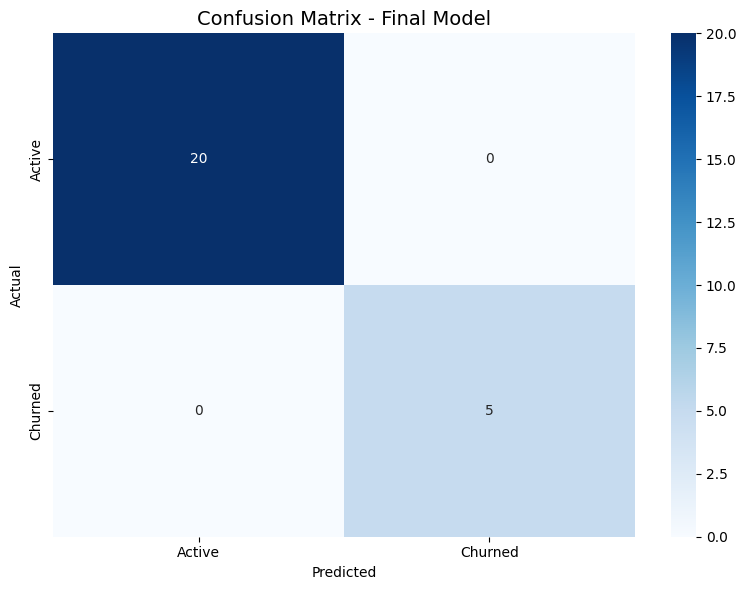

 Saved: confusion_matrix.png


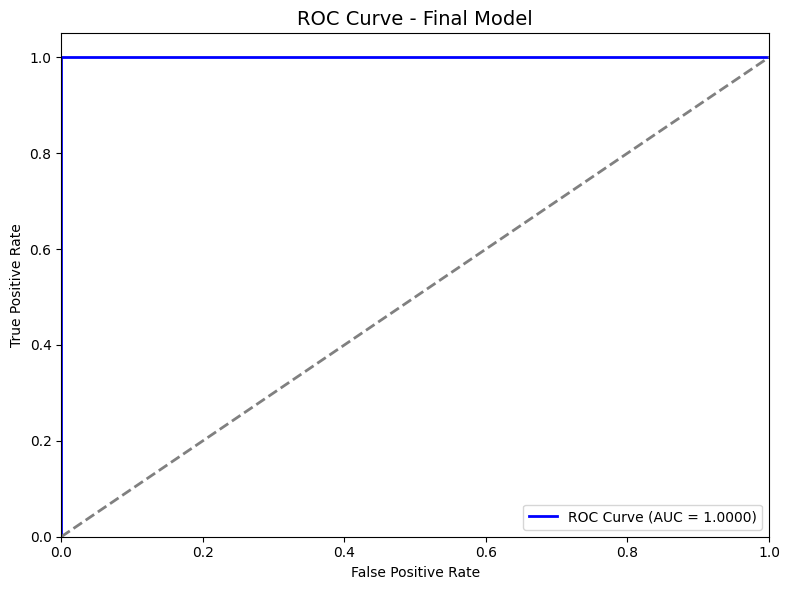

 Saved: roc_curve.png


In [17]:
# =============================================================================
# 13. FINAL MODEL EVALUATION
# =============================================================================
print("\n" + "="*80)
print("STEP 13: FINAL MODEL EVALUATION")
print("="*80)

# Predictions
y_pred_final = final_model.predict(X_test_scaled)
y_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

print("\n Final Model Performance on Test Set:")
print("-"*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_final):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Active', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title('Confusion Matrix - Final Model', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()
print(" Saved: confusion_matrix.png")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba_final):.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()
print(" Saved: roc_curve.png")


In [18]:
# =============================================================================
# 14. FEATURE IMPORTANCE ANALYSIS
# =============================================================================
print("\n" + "="*80)
print("STEP 14: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance (for tree-based models)
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\n Top 15 Most Important Features:")
    print(feature_importance.head(15).to_string(index=False))

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title('Top 15 Feature Importance - Churn Prediction', fontsize=14)
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100)
    plt.show()
    print(" Saved: feature_importance.png")

elif hasattr(final_model, 'coef_'):
    # For logistic regression
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': np.abs(final_model.coef_[0])
    }).sort_values('Importance', ascending=False)

    print("\n Top 15 Most Important Features (by coefficient magnitude):")
    print(feature_importance.head(15).to_string(index=False))


STEP 14: FEATURE IMPORTANCE ANALYSIS

 Top 15 Most Important Features (by coefficient magnitude):
            Feature  Importance
           Feedback    0.450620
      Payment_Ratio    0.379154
  Avg_Call_Duration    0.352655
  Max_Call_Duration    0.328431
Total_Call_Duration    0.319071
  Min_Call_Duration    0.311780
        Paid_amount    0.297781
 Days_Since_Payment    0.291491
  Induction_Session    0.240359
    has_no_response    0.213102
     Call_Frequency    0.173362
        Total_Calls    0.173362
             Course    0.162457
     Payment_Method    0.129314
     Executive_Team    0.124715


In [19]:
# =============================================================================
# 15. CHURN REASON EXTRACTION
# =============================================================================

print("\nExtracting suggested churn reasons for churned candidates based on call remarks and feedback...")

# Aggregate all call remarks per candidate into a single text blob
def aggregate_remarks_by_candidate(call_log_df):
    if 'Call_Remarks' not in call_log_df.columns:
        return pd.DataFrame(columns=['Candidate_ID', 'All_Call_Remarks'])
    grouped = call_log_df.groupby('Candidate_ID')['Call_Remarks'].apply(
        lambda x: ' '.join(x.dropna().astype(str))
    ).reset_index(name='All_Call_Remarks')
    return grouped


def suggest_reason_from_text(remarks_text, feedback_text):
    text = ''
    if pd.notna(remarks_text):
        text += str(remarks_text).lower() + ' '
    if pd.notna(feedback_text):
        text += str(feedback_text).lower()

    # Priority-based keyword matching
    if any(k in text for k in ['pay', 'payment', 'fee', 'installment', 'emi', 'finance', 'financial']):
        return 'Financial issues'
    if any(k in text for k in ['not interested', 'no interest', 'lack of interest', 'lost interest', 'not keen', 'disinterested', 'no longer interested']):
        return 'Lack of interest'
    if any(k in text for k in ['joined another', 'joined other', 'admission elsewhere', 'admitted', 'migrated to', 'joined institute', 'joined company', 'enrolled elsewhere']):
        return 'Joined another institution'
    if any(k in text for k in ['no response', 'no pickup', 'unreachable', 'voicemail', 'did not pick', 'not reachable', 'no answer', 'call dropped', 'busy', 'no contact', 'not responding']):
        return 'Communication gaps'

    # Fallbacks based on short signals
    if any(k in text for k in ['course not suitable', 'course mismatch', 'course not for me', 'content not relevant']):
        return 'Lack of interest'

    return 'Other'


# Build aggregated remarks and merge with the main dataframe `df`
remarks_agg = aggregate_remarks_by_candidate(call_log)
df_with_remarks = df.merge(remarks_agg, on='Candidate_ID', how='left')

# Ensure Feedback column exists
if 'Feedback' not in df_with_remarks.columns:
    df_with_remarks['Feedback'] = np.nan

# Generate suggested reasons for all candidates (we'll filter churned ones afterwards)
df_with_remarks['Suggested_Churn_Reason'] = df_with_remarks.apply(
    lambda r: suggest_reason_from_text(r.get('All_Call_Remarks', ''), r.get('Feedback', '')),
    axis=1
)

# Prepare output for churn candidates
churn_reasons_df = df_with_remarks.loc[df_with_remarks['Churn'] == 1, [
    'Candidate_ID', 'Churn', 'Suggested_Churn_Reason', 'All_Call_Remarks', 'Feedback'
]].copy()

if churn_reasons_df.empty:
    print(' No churn candidates found to suggest reasons for.')
else:
    churn_reasons_df.to_csv('churn_reasons.csv', index=False)
    print(' Saved churn reasons to: churn_reasons.csv')

# Also save the full dataset with suggested reasons for inspection
df_with_remarks.to_csv('candidates_with_suggested_reasons.csv', index=False)
print(' Saved full candidate reason dataset to: candidates_with_suggested_reasons.csv')


Extracting suggested churn reasons for churned candidates based on call remarks and feedback...
 Saved churn reasons to: churn_reasons.csv
 Saved full candidate reason dataset to: candidates_with_suggested_reasons.csv


In [20]:
# =============================================================================
# 16. MODEL SAVING
# =============================================================================
print("\n" + "="*80)
print("STEP 16: MODEL SAVING")
print("="*80)

import pickle

# Save the final model
model_data = {
    'model': final_model,
    'model_name': final_model_name,
    'model_display_name': final_model_name,
    'scaler': scaler,
    'feature_columns': feature_columns,
    'label_encoders': label_encoders,
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'balance_method': balance_method
}

with open('churn_prediction_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(" Model saved to: churn_prediction_model.pkl")

# Save feature importance report
feature_importance.to_csv('feature_importance_report.csv', index=False)
print(" Feature importance saved to: feature_importance_report.csv")

# Save model evaluation results
results_df.to_csv('model_evaluation_results.csv', index=False)
print(" Model evaluation results saved to: model_evaluation_results.csv")



STEP 16: MODEL SAVING
 Model saved to: churn_prediction_model.pkl
 Feature importance saved to: feature_importance_report.csv
 Model evaluation results saved to: model_evaluation_results.csv


In [21]:
# =============================================================================
# 17. SUMMARY
# =============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"""
 CHURN PREDICTION MODEL BUILD COMPLETE!

 Data Loading: Loaded 3 datasets (Candidate Profile, Call Log, Executive Profile)
 Data Handling: Processed missing values and date columns
 Data Preprocessing: Normalized numerical features, encoded categorical features
 Feature Engineering: Created 19+ features from call logs and executive data
 Balancing Technique: Selected {balance_method} using validation F1 score
 Model Evaluation: Compared 9 different ML algorithms
 Cross-Validation: Checked for overfitting using 5-fold CV
 Hyperparameter Tuning: Optimized best model using GridSearchCV
 Regularization: Applied regularization techniques to prevent overfitting

 Output Files:
   - churn_prediction_model.pkl (Trained model)
   - feature_importance_report.csv (Feature importance rankings)
   - model_evaluation_results.csv (Model comparison results)
   - confusion_matrix.png (Confusion matrix visualization)
   - roc_curve.png (ROC curve visualization)
   - feature_importance.png (Feature importance chart)
   - churn_distribution.png (Target variable distribution)

 Best Model: {final_model_name}
 Final Performance:
   - Accuracy: {accuracy_score(y_test, final_pred) * 100:.2f}%
   - F1 Score: {f1_score(y_test, final_pred):.4f}
   - ROC-AUC: {roc_auc_score(y_test, final_proba):.4f}

""")

print("="*80)


SUMMARY

 CHURN PREDICTION MODEL BUILD COMPLETE!

 Data Loading: Loaded 3 datasets (Candidate Profile, Call Log, Executive Profile)
 Data Handling: Processed missing values and date columns
 Data Preprocessing: Normalized numerical features, encoded categorical features
 Feature Engineering: Created 19+ features from call logs and executive data
 Balancing Technique: Selected none using validation F1 score
 Model Evaluation: Compared 9 different ML algorithms
 Cross-Validation: Checked for overfitting using 5-fold CV
 Hyperparameter Tuning: Optimized best model using GridSearchCV
 Regularization: Applied regularization techniques to prevent overfitting

 Output Files:
   - churn_prediction_model.pkl (Trained model)
   - feature_importance_report.csv (Feature importance rankings)
   - model_evaluation_results.csv (Model comparison results)
   - confusion_matrix.png (Confusion matrix visualization)
   - roc_curve.png (ROC curve visualization)
   - feature_importance.png (Feature importa